# Linear Regression

## Review: What is Machine Learning?

1.  **Supervised Learning:** Learning from data that is **labeled**. You provide the algorithm with examples of inputs and their corresponding correct outputs. The goal is to learn a general rule that maps inputs to outputs. (This is our focus today).
2.  **Unsupervised Learning:** Learning from data that is **unlabeled**. The algorithm tries to find patterns, structures, or clusters in the data on its own.
3.  **Reinforcement Learning:** An agent learns to perform actions in an environment to maximize a cumulative reward. It learns by trial and error.

## Supervised Learning

> **Supervised Learning:** Given a dataset of input features **X** and corresponding output labels **y**, we want to learn a function `h` (for hypothesis) such that `h(X)` is a good predictor for **y**.

There are two primary types of supervised learning problems:

### A. Regression: Predicting a Continuous Value
The output `y` is a continuous, numerical value.
- **Question:** Based on a material's temperature, what will its electrical resistance be?
- **Question:** Given the mass of a star, what is its expected luminosity?
- **Our main tool today:** **Linear Regression** See [Visually Explained: Linear regression](https://www.youtube.com/watch?v=CtsRRUddV2s)

### B. Classification: Predicting a Discrete Category
The output `y` is a discrete category or class label.
- **Question:** Based on a cell's size and shape, is it cancerous or benign?
- **Question:** Given the energy and momentum from a particle collider, did we detect an electron or a muon?
- **A common tool:** **Logistic Regression** (despite its name, it's for classification!)

| Feature | Linear Regression | Logistic Regression |
| :---- | :---- | :---- |
| **Problem Type** | Regression (predicting continuous values) | Classification (predicting categorical outcomes) |
| **Output** | Continuous numerical value (e.g., price, temperature) | Probability (0 to 1), which is then mapped to a class |
| **Dependent Variable** | Continuous | Categorical (binary or multi-class) |
| **Underlying Function** | Linear equation: $y=\beta_0 + \beta_1 x_1 + \cdots \beta_n x_n$ | Sigmoid (logistic) function applied to a linear equation: $p=1/(1+\exp(−(\beta_0 + \beta_1 x_1 + \cdots \beta_n x_n))$ |
| **Cost Function** | Mean Squared Error (MSE), Root Mean Squared Error (RMSE) | Log Loss (Binary Cross-Entropy), Cross-Entropy |
| **Interpretation of Coefficients** | Change in the dependent variable for a one-unit change in the independent variable | Change in the log-odds of the dependent variable for a one-unit change in the independent variable |
| **Assumptions** | Linearity, independence of errors, homoscedasticity, normality of residuals, no multicollinearity | Linearity of independent variables with log-odds, independence of observations, no multicollinearity |
| **Common Use Cases** | Predicting house prices, sales forecasting, predicting exam scores, trend analysis | Spam detection, disease prediction (e.g., presence/absence), customer churn prediction, sentiment analysis |
| **Evaluation Metrics** | MSE, RMSE, R-squared, MAE | Accuracy, Precision, Recall, F1-Score, ROC-AUC |

## The bias-variance tradeoff
For all models, you should always keep in mind the bias-variance tradeoff
:::{figure} https://media.geeksforgeeks.org/wp-content/uploads/20251212100155481380/70830267-.webp
:alt: Bias-variance
:width: 70%
:align: center
REF: <https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/>
:::



```{figure} https://docs.aws.amazon.com/images/machine-learning/latest/dg/images/mlconcepts_image5.png
:alt: Low bias high variance
:width: 70%
:align: center
REF: <https://docs.aws.amazon.com/machine-learning/latest/dg/model-fit-underfitting-vs-overfitting.html>
```

If your model has a low bias, then it might be overfitting the training data and then it will increase the predictions variance (imagine using a very large polynomial to do a fit). If your model has low variance, it might be underfitting, so the bias will be large. Check
- <https://www.ibm.com/think/topics/bias-variance-tradeoff>
- <https://mlu-explain.github.io/bias-variance/>.

### The Bias-Variance Tradeoff Deduction

Given a model $\hat{f}(x; w)$ trained on data $\mathcal{D}$, and a true target generated by:

\begin{equation}
y = f(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)
\end{equation}

We want to understand the **expected prediction error** at a point $x$:

\begin{equation}
\mathbb{E}_{\mathcal{D},\varepsilon}\left[(y - \hat{f}(x))^2\right]
\end{equation}


---

#### Decomposition

Expand by adding and subtracting $\mathbb{E}_{\mathcal{D}}(\hat{f}(x))$, the **mean prediction** over all possible training sets:


$$
\mathbb{E}\left[(y - \hat{f})^2\right] = \mathbb{E}\left[\left(y - \bar{f} + \bar{f} - \hat{f}\right)^2\right]
$$

where $\bar{f} \equiv \mathbb{E}_\mathcal{D}[\hat{f}(x)]$.

Expanding the square and noting that cross-terms vanish (noise $\varepsilon$ is independent of $\hat{f}$):

\begin{equation}
\to \underbrace{\mathbb{E}\left[(y - \bar{f})^2\right]}_{\text{expand further}} + \underbrace{\mathbb{E}\left[(\bar{f} - \hat{f})^2\right]}_{\text{Variance}}
\end{equation}

For the first term, write $y = f(x) + \varepsilon$ and add/subtract $f(x)$:

$$
\mathbb{E}\left[(y - \bar{f})^2\right]
= \underbrace{(f(x) - \bar{f})^2}_{\text{Bias}^2} + \underbrace{\sigma^2}_{\text{Noise}}
$$


---

#### Result

\begin{equation}
\boxed{
\mathbb{E}\left[(y - \hat{f})^2\right] = \underbrace{(f(x) - \mathbb{E}[\hat{f}])^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f} - \mathbb{E}[\hat{f}])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}
}
\end{equation}


---

### Interpretation

| Term | Meaning | Reduced by... |
|------|---------|---------------|
| **Bias²** | How wrong our model is *on average* | More complex models |
| **Variance** | How much our model fluctuates across datasets | Simpler models, more data |
| **Noise** $\sigma^2$ | Irreducible randomness in the data | Nothing — fundamental limit |

> **The tradeoff:** Increasing model complexity reduces bias but raises variance. The goal is to find the sweet spot that minimizes total expected error.

## Linear Regression introduction

Linear Regression is one of the simplest and most interpretable machine learning models. It assumes a linear relationship between the input features and the output variable.

In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Set the renderer to 'notebook' for Jupyter Book compatibility
pio.renderers.default = "jupyterlab"

def generate_and_plot_regression_problems_plotly():
    """
    Generates data and plots interactive 2D and 3D linear regression problems vertically stacked.
    """
    # --- CHANGE 1: Set rows=2, cols=1 and update specs to a 2x1 list ---
    fig = make_subplots(
        rows=2, cols=1,
        specs=[[{'type': 'xy'}], [{'type': 'surface'}]],
        subplot_titles=('2D Linear Regression Problem', '3D Linear Regression Problem (Plane)'),
        vertical_spacing=0.15 # Adds space between the top and bottom plot
    )

    # --- Left/Top Subplot: 2D Linear Regression Problem ---
    np.random.seed(4_2)
    x_2d = np.linspace(0, 10, 50)
    true_slope = 2.5
    true_intercept = 5
    y_true_2d = true_slope * x_2d + true_intercept
    noise_2d = np.random.normal(0, 2, size=len(x_2d))
    y_noisy_2d = y_true_2d + noise_2d

    # This stays in row=1, col=1
    fig.add_trace(
        go.Scatter(x=x_2d, y=y_true_2d, mode='lines', name='True Line', line=dict(color='red')),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=x_2d, y=y_noisy_2d, mode='markers', name='Noisy Data', marker=dict(color='blue')),
        row=1, col=1
    )

    # --- Right/Bottom Subplot: 3D Plane Regression Problem ---
    x_3d = np.linspace(-5, 5, 20)
    y_3d = np.linspace(-5, 5, 20)
    X_3d, Y_3d = np.meshgrid(x_3d, y_3d)
    true_coeff_x = 1.2
    true_coeff_y = -0.8
    true_intercept_3d = 3
    Z_true_3d = true_coeff_x * X_3d + true_coeff_y * Y_3d + true_intercept_3d
    noise_3d = np.random.normal(0, 1.5, size=Z_true_3d.shape)
    Z_noisy_3d = Z_true_3d + noise_3d

    # --- CHANGE 2: Update trace assignment from (row=1, col=2) to (row=2, col=1) ---
    fig.add_trace(
        go.Surface(x=X_3d, y=Y_3d, z=Z_true_3d, opacity=0.7, colorscale='viridis', name='True Plane', showscale=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter3d(
            x=X_3d.flatten(), y=Y_3d.flatten(), z=Z_noisy_3d.flatten(),
            mode='markers',
            marker=dict(size=4, color='red'),
            name='Noisy Data'
        ),
        row=2, col=1
    )

    # --- CHANGE 3: Adjust Height and Width for vertical stacking ---
    fig.update_layout(
        title_text='Linear Regression Examples',
        height=900, # Increased height so the two plots aren't squashed
        width=800,  # Reduced width to look better in a single column
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig.update_xaxes(title_text="X", row=1, col=1)
    fig.update_yaxes(title_text="Y", row=1, col=1)
    return fig

# Generate and show
fig_regression_problems_plotly = generate_and_plot_regression_problems_plotly()
fig_regression_problems_plotly.show()


### Some applications to basic sciences
Physics and Statistical Physics (Linear Regression/Ridge Regression)

- Alexander Mozeika, Mansoor Sheikh, Fabian Aguirre-Lopez, Fabrizio Antenucci, and Anthony C. C. Coolen (2021). Exact results on high-dimensional linear regression via statistical physics. PHYSICAL REVIEW E, 103, 042142 (2021). DOI/Link <doi.org/10.1103/PhysRevE.103.042142>
- J. Barbier, F. Krzakala, N. Macris, L. Miolane, and L. Zdeborová (2019). The statistical physics of ridge regression and the bias-variance trade-off. Proceedings of the National Academy of Sciences U.S.A., 116, 5451 (2019)
- M. Advani and S. Ganguli (2016). Statistical physics of high-dimensional inference: The linear regression model. Physical Review X, 6, 031034 (2016)

Materials Science and Engineering (Linear Regression/Knowledge Discovery)

- Doreswamy, Hemanth K S, and Manohar M G (2011). Linear Regression Model for Knowledge Discovery in Engineering Materials. AIAA 2011, CS & IT 03, pp. 147–156 (2011) . DOI/Link: 10.5121/csit.2011.1313
- A. M. Deml, R. O’Hayre, C. Wolverton, and V. Stevanović (2016). Predicting density functional theory total energies and enthalpies of formation of metal-nonmetal compounds by linear regression. Phys. Rev. B: Condens. Matter Mater. Phys., 93, 085142 (2016)

Biology and Genomics (Linear Models/RNA-Seq and Microarray)

- M. E. Ritchie, B. Phipson, D. Wu, Y. Hu, C. W. Law, W. Shi, and G. K. Smyth (2015). limma powers differential expression analyses for RNA-sequencing and microarray studies. Nucleic Acids Research, 43(7), e47 (2015)
- C. W. Law, Y. Chen, W. Shi, and G. K. Smyth (2014). Voom: precision weights unlock linear model analysis tools for RNA-seq read counts. Genome Biology, 15, R29 (2014)

Chemistry, Analytical Chemistry, and Drug Design (Multiple Linear Regression - MLR)

- J. I. García, H. García-Marín, J. A. Mayoral, and P. Pérez (2013). Quantitative structure-property relationships prediction of some physic-chemical properties of glycerol based solvents. Green Chemistry, 15, 2283–2293 (2013)
- A. G. A. Jameel, N. Naser, A-H. Emwas, S. Dooley, and S. M. Sarathy (2016). Predicting fuel ignition quality using 1H NMR spectroscopy and multiple linear regression.  Energy & Fuels, 30, 9819–9835 (2016)

Environmental Science and Planning (Linear and Spatial Regression Models)

- Sanqing He, Yanan Sun, Ningyi Zeng, Lei Wang, Zihan Cao, and Zhen He (2025). Regional divergence in the urban form-carbon emission nexus: a comparative analysis of linear and non-linear spatial modeling approaches for 286 Chinese cities. Frontiers in Environmental Science, 13:1658538 (2025).  10.3389/fenvs.2025.1658538

### The Goal
To find the "best-fit" line that describes the data. For a single input feature `x` (1D regression), the equation of the line is:

\begin{equation}
\hat{y} = \theta_0 + \theta_1 x
\end{equation}


Where:
- $\hat{y}$ (y-hat) is the **predicted value**.
- $x$ is the **input feature**.
- $\theta_0$ (theta-zero) is the **y-intercept** (also called the bias). It's the value of $\hat{y}$ when $x=0$.
- $\theta_1$ (theta-one) is the **slope** or **coefficient**. It represents the change in $\hat{y}$ for a one-unit change in $x$.

In general,

\begin{equation}
\hat{y}_i = \vec \theta^T \vec x_i,
\end{equation}

where $x_i = [1, x_1, x_2, \ldots, x_d] \in \mathbb{R}^{d+1}$, and $\theta_i = [\theta_0, \theta_1, \ldots, \theta_d] \in \mathbb{R}^{d+1}$, for $d$ features.

```{note} Notation: $\vec \theta = \vec w$
Sometimes, we will use $\vec w$ instead of $\vec\theta$ for the parameters.
```

```{note} The full data is a Matrix
Given that we have $n$ measures for $\vec x_i$, and $x_i \in \mathbb{R}^{d+1}$, then we can represent the $x\times (d+1)$ data matrix as
\begin{equation}
X =
\begin{pmatrix}
1 & x_{11} & x_{12} & \ldots & x_{1d}\\
1 & x_{21} & x_{22} & \ldots & x_{2d}\\
\vdots & \vdots & \vdots & \ldots & \vdots\\
1 & x_{n1} & x_{n2} & \ldots & x_{nd}\\
\end{pmatrix}.
\end{equation}

Therefore, the product $\vec w^T \vec x_i = \vec w \cdot \vec x_i  = (X \vec w)_i, \ i \in [1, n]$.

```

```{important} Linear regression allows for non-linear functions
Please note that linear regression can be applied to non-linear functions on $\vec x$. Linear regression is linear only in the parameters, so the problema can also be stated the the hypothesis is
\begin{equation}
\hat y_i = \vec w \cdot \vec \phi (\vec x_i),
\end{equation}
where $\phi$ is any function.

```

Our goal is to find the optimal values for $\theta_0$ and $\theta_1$ that make our line fit the data as closely as possible. We are going to follow to paths to do this: the classical exact solution, and the ML (gradient descent) way.


| Aspect | Classical (Analytical) | Machine Learning (Gradient Descent) |
|--------|----------------------|-------------------------------------|
| **Mathematical Foundation** | Calculus: $\partial/\partial\theta = 0$ | Optimization: $\theta = \theta -\alpha \nabla\theta$ |
| **Solution Type** | Exact (closed-form) | Iterative approximation |
| **Computation Time** | Fast (single calculation) | Slower (many iterations) |
| **Memory Requirements** | Can handle large datasets | May need batch processing |
| **Scalability** | Limited by matrix operations | Scales to massive datasets |
| **Interpretability** | Direct mathematical insight | Requires convergence analysis |
| **Flexibility** | Fixed to linear relationships | Easily extended (regularization, non-linear) |
| **Noise Handling** | Assumes well-behaved data | Naturally robust to outliers |
| **Implementation** | `np.linalg.lstsq()` or `statsmodels` | Custom loops or `SGDRegressor` |
| **When to Use** | Small-medium datasets, interpretability needed | Large datasets, part of ML pipeline |

**The Key Insight**

Both methods minimize the **same cost function**:

\begin{equation}
\text{MSE} = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
\end{equation}


- **Classical**: Solves $\nabla$MSE = 0 analytically
- **ML**: Follows $\nabla$MSE downhill iteratively

```{iframe} https://www.geogebra.org/m/c3yu9zsk
:width: 90%
Linear regression
```

## The implications of assuming a distribution for the errors
Although this is assumed implicitly, for the mean squared error and the criteria shown before we are assuming that
$$\epsilon \sim \mathcal{N}(0, \sigma^2).$$
What implications does it have? let's make the deduction.

### The Model Assumption
We assume a linear relationship between the input $x$ and the target $y$, subject to additive Gaussian noise $\epsilon$:
$$y = w^T x + \epsilon$$
Where the noise $\epsilon$ is assumed to be Independent and Identistically Distributed (IID) following a normal distribution with zero mean and variance $\sigma^2$:
$$\epsilon \sim \mathcal{N}(0, \sigma^2)$$

### The Probability Density Function (PDF)
Since $y$ is the sum of a deterministic prediction ($w^T x$) and a Gaussian random variable ($\epsilon$), the conditional probability of an observation $y_i$ given $x_i$ and parameters $w$ is:
$$p(y_i \mid x_i, w, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right)$$

### The Likelihood Function
For a dataset $\mathcal{D}$ of $n$ IID observations $\{(x_1, y_1), \dots, (x_n, y_n)\}$, the **Likelihood Function** $L(w)$ is the joint probability of all observations. Due to independence, this is the product of individual probabilities:
$$L(w) = \prod_{i=1}^{n} p(y_i \mid x_i, w, \sigma^2)$$
$$L(w) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right)$$

### The Log-Likelihood
Maximizing the product is computationally difficult. We instead maximize the **Log-Likelihood** ($\ell$), as the natural logarithm is a monotonic transformation:
$$\ell(w) = \ln(L(w)) = \sum_{i=1}^{n} \ln\left( \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right) \right)$$

Using logarithm properties ($\ln(abc) = \ln a + \ln b$):
$$\ell(w) = \sum_{i=1}^{n} \left[ \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{(y_i - w^T x_i)^2}{2\sigma^2} \right]$$
$$\ell(w) = n \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2$$

### From Maximum Likelihood to Mean Squared Error
To find the optimal $w$, we seek to **maximize** $\ell(w)$.
The first term ($n \ln(\dots)$) is a constant with respect to $w$. Therefore, maximizing $\ell(w)$ is equivalent to:
$$\text{maximize} \left[ - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 \right]$$

By multiplying the objective by $-2\sigma^2$ (which flips the maximization to a minimization problem), we arrive at:
$$\text{minimize} \sum_{i=1}^{n} (y_i - w^T x_i)^2$$

### Conclusion
The derivation proves that **minimizing the Sum of Squared Errors (SSE)** is mathematically equivalent to performing **Maximum Likelihood Estimation** under the assumption of Gaussian noise.


The following shows some data that does not follow the normality of residuals assumption

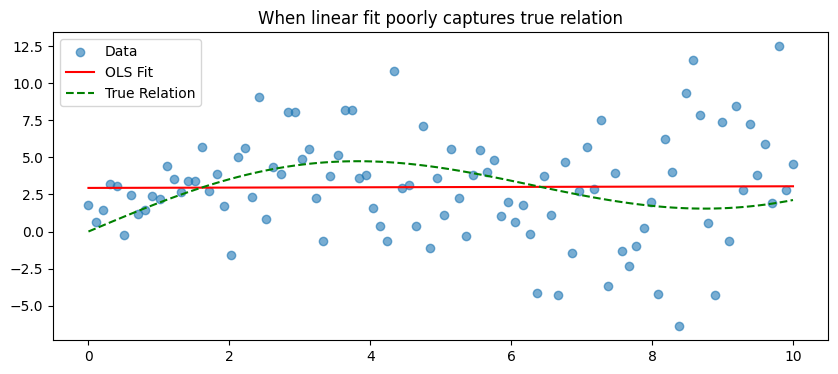

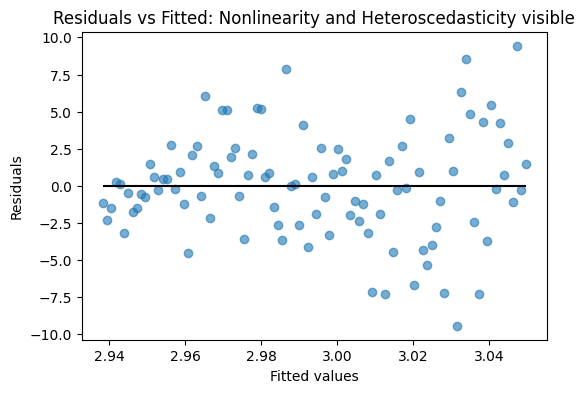

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# Simulate nonlinear relation + heteroscedastic noise
x = np.linspace(0, 10, 100)
y_true = 3 * np.sin(x / 2) + 0.5 * x
noise = np.random.normal(0, 1 + 0.5 * x, size=x.shape) # NOTE: The standard deviation depends on X, so it is not constant
y = y_true + noise

# Fit simple linear regression
from sklearn.linear_model import LinearRegression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(10,4))
plt.scatter(x, y, label='Data', alpha=0.6)
plt.plot(x, y_pred, color='red', label='OLS Fit')
plt.plot(x, y_true, color='green', linestyle='dashed', label='True Relation')
plt.legend()
plt.title("When linear fit poorly captures true relation")
plt.show()

# Residuals
resid = y - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, resid, alpha=0.6)
plt.hlines(0, min(y_pred), max(y_pred), color='black')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted: Nonlinearity and Heteroscedasticity visible')
plt.show()


## Exact approach to find the best parameters
For this simple example, computing both parameters is "easily" done by defining a metric to minimize, computing its partial derivatives, making them null and then computing the parameters. The distance from a giving predicted pint from its corresponding data is $(\hat y_i - y_i)^2$, and it is squared to take into account values over or under estimating the data. We can define the **MEAN SQUARED ERROR** as

\begin{equation}
\Delta (\theta_0, \theta_1) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 = \frac{1}{2n} \sum_{i=1}^{n} ((\theta_0 + \theta_1 x_i) - y_i)^2,
\end{equation}
and the goal is to minimize it.

In this simple case, we can compute $\partial \Delta/\partial \theta_0 = 0$ and $\partial \Delta/\partial \theta_1 = 0$, and from it arrive to
\begin{align}
\theta_1 &= \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2},\\\\
\theta_0 &= \frac{\sum y_i - \theta_1\sum x_i}{n}.
\end{align}

In the full $d-$dimensional case, the so-called Ordinary Least Square (OLS) problem, we have
\begin{equation}
\vec \theta = \vec w = (X^TX)^{-1}X^T\vec y ,
\end{equation}
where we have the so-caled pseudo-inverse of $X$. This exact formulation is sensible to the matrix dimensions, and is not recommended for large $n$ or $d$.

Key Scenarios Where OLS Fails:

- High-Dimensional Data: When the number of features (parameters to estimate) exceeds the number of observations (e.g., genetic datasets, genomic studies), the matrix is singular, meaning it has no unique inverse, making it impossible to compute.
- Large-Scale Data and Memory Limitations: When the data matrix has millions of rows (observations) and columns (features), the computational cost to store and invert becomes prohibitively expensive, exceeding computer memory capacity
- Near-Collinearity (Badly Conditioned Matrix): If features are highly correlated, the matrix is near-singular (badly conditioned). While a direct inverse may technically exist, it leads to immense numerical instability and unreliable, volatile coefficient estimates, often leading to failures in standard numerical solvers.

Common Alternatives in These Cases:
- Iterative Optimization (Gradient Descent): Replaces the exact closed-form solution with an approximation that scales better.
- Regularization (Ridge/Lasso): Introduces a penalty term to handle singular or near-singular matrices.
- Dimensionality Reduction (PCA): Reduces the number of features to handle high-dimensional data.



## Gradient Descent to find the best parameters: Learning from data

**Analogy:** Imagine you are a hiker in a foggy valley and you want to get to the lowest point. You can't see the whole valley, but you can feel the slope of the ground right under your feet. What do you do? You take a step in the steepest downward direction.

This is exactly what Gradient Descent does:
1.  Start with some random values for $\theta_0$ and $\theta_1$.
2.  Calculate the gradient (the "slope") of the cost function at that point.
3.  Take a small step in the opposite direction of the gradient (downhill).
4.  Repeat until you reach the bottom (the minimum), where the slope is zero.

In [3]:
%%html
<!-- Load Plotly.js -->
<script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

<!-- Create the Custom HTML Sliders (UI) -->
<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; border: 1px solid #ddd; margin-bottom: 15px;">
    <div style="display: flex; flex-wrap: wrap; gap: 20px; align-items: center;">

        <div style="display: flex; flex-direction: column;">
            <label style="font-weight: bold; font-size: 0.9em;">Learn Rate: <span id="val-lr" style="color: #d9534f;">0.08</span></label>
            <input type="range" id="ui-lr" min="0.01" max="1.5" step="0.01" value="0.08" style="width: 140px;">
        </div>

        <div style="display: flex; flex-direction: column;">
            <label style="font-weight: bold; font-size: 0.9em;">Start X: <span id="val-x0" style="color: #d9534f;">2.5</span></label>
            <input type="range" id="ui-x0" min="-2.8" max="2.8" step="0.1" value="2.5" style="width: 140px;">
        </div>

        <div style="display: flex; flex-direction: column;">
            <label style="font-weight: bold; font-size: 0.9em;">Start Y: <span id="val-y0" style="color: #d9534f;">2.5</span></label>
            <input type="range" id="ui-y0" min="-2.8" max="2.8" step="0.1" value="2.5" style="width: 140px;">
        </div>

        <div style="display: flex; flex-direction: column;">
            <label style="font-weight: bold; font-size: 0.9em;">Steps: <span id="val-steps" style="color: #d9534f;">80</span></label>
            <input type="range" id="ui-steps" min="20" max="200" step="10" value="80" style="width: 140px;">
        </div>

        <div style="display: flex; flex-direction: column;">
            <label style="font-weight: bold; font-size: 0.9em;">Roughness: <span id="val-noise" style="color: #d9534f;">0.0</span></label>
            <input type="range" id="ui-noise" min="0.0" max="2.0" step="0.1" value="0.0" style="width: 140px;">
        </div>

        <div>
            <button id="btn-play" style="padding: 8px 16px; background: #007bff; color: white; border: none; border-radius: 4px; cursor: pointer; font-weight: bold;">▶ Play Animation</button>
        </div>

    </div>
</div>

<!-- Div where Plotly will draw the 3D graph -->
<div id="js-gd-plot" style="width: 100%; height: 750px;"></div>

<!-- The Javascript Logic -->
<script>
(function() { // Wrap in an IIFE so variables don't pollute the global Jupyter window

    // 1. Math Functions
    const f = (x, y, noise) => Math.sin(x)*Math.cos(y) + 0.3*(x*x + y*y) + noise*Math.sin(2.3*x)*Math.sin(2.7*y);

    // Create Meshgrid for the surface
    const xs = [], ys =[];
    for(let i = -3; i <= 3.01; i += 0.1) { xs.push(i); ys.push(i); }

    function getSurfaceZ(noise) {
        let Z =[];
        for(let j=0; j<ys.length; j++) {
            let row =[];
            for(let i=0; i<xs.length; i++) {
                row.push(f(xs[i], ys[j], noise));
            }
            Z.push(row);
        }
        return Z;
    }

    // Gradient Descent Algorithm Loop in pure Javascript
    function runGD(lr, x0, y0, n_steps, noise) {
        let cx = x0, cy = y0;
        let px = [cx], py = [cy], pz = [f(cx, cy, noise)];
        const eps = 1e-5;
        for(let i=0; i<n_steps; i++) {
            let gx = (f(cx+eps, cy, noise) - f(cx-eps, cy, noise)) / (2*eps);
            let gy = (f(cx, cy+eps, noise) - f(cx, cy-eps, noise)) / (2*eps);
            cx -= lr * gx;
            cy -= lr * gy;
            // Clip constraints [-3, 3]
            cx = Math.max(-3, Math.min(3, cx));
            cy = Math.max(-3, Math.min(3, cy));
            px.push(cx); py.push(cy); pz.push(f(cx, cy, noise));
        }
        return {px, py, pz};
    }

    let isAnimating = false;
    let animInterval = null;

    // 2. Initialize and Update Functions
    function updatePlot(mode = 'instant') {
        // Read values from HTML sliders
        let lr = parseFloat(document.getElementById('ui-lr').value);
        let x0 = parseFloat(document.getElementById('ui-x0').value);
        let y0 = parseFloat(document.getElementById('ui-y0').value);
        let steps = parseInt(document.getElementById('ui-steps').value);
        let noise = parseFloat(document.getElementById('ui-noise').value);

        // Update labels on the UI
        document.getElementById('val-lr').innerText = lr.toFixed(2);
        document.getElementById('val-x0').innerText = x0.toFixed(1);
        document.getElementById('val-y0').innerText = y0.toFixed(1);
        document.getElementById('val-steps').innerText = steps;
        document.getElementById('val-noise').innerText = noise.toFixed(1);

        // Calculate Math
        let path = runGD(lr, x0, y0, steps, noise);
        let Z = getSurfaceZ(noise);

        if (mode === 'init' || mode === 'instant') {
            clearInterval(animInterval);
            isAnimating = false;

            let data =[
                { type: 'surface', x: xs, y: ys, z: Z, colorscale: 'RdBu', reversescale: true, opacity: 0.82, showscale: false, name: 'Loss' },
                { type: 'scatter3d', mode: 'lines+markers', x: path.px, y: path.py, z: path.pz, line: {color: 'orange', width: 5}, marker: {size: 4, color: 'orange'}, name: 'Path' },
                { type: 'scatter3d', mode: 'markers', x:[path.px[path.px.length-1]], y: [path.py[path.py.length-1]], z: [path.pz[path.pz.length-1]], marker: {size: 10, color: 'white', line: {color: 'orange', width: 2}}, name: 'End' }
            ];

            let layout = {
                title: `Gradient Descent (lr=${lr.toFixed(2)})`,
                margin: {l: 0, r: 0, b: 0, t: 40},
                scene: { xaxis: {title: 'x'}, yaxis: {title: 'y'}, zaxis: {title: 'f(x,y)'}, camera: {eye: {x: 1.6, y: 1.6, z: 1.1}} }
            };

            Plotly.react('js-gd-plot', data, layout);
        }
        else if (mode === 'play' && !isAnimating) {
            isAnimating = true;
            let currentStep = 0;

            // Loop animation natively using setInterval
            animInterval = setInterval(() => {
                if(currentStep >= path.px.length) {
                    clearInterval(animInterval);
                    isAnimating = false;
                    return;
                }
                // Extremely fast Plotly update targeting only the line (Trace 1) and ball (Trace 2)
                Plotly.restyle('js-gd-plot', {
                    x: [path.px.slice(0, currentStep+1),[path.px[currentStep]]],
                    y: [path.py.slice(0, currentStep+1), [path.py[currentStep]]],
                    z: [path.pz.slice(0, currentStep+1),[path.pz[currentStep]]]
                }, [1, 2]); // <- Only updates traces 1 and 2, ignores the 3D surface!

                currentStep++;
            }, 60); // 60ms delay per frame
        }
    }

    // 3. Attach Listeners to sliders
    const sliders =['ui-lr', 'ui-x0', 'ui-y0', 'ui-steps', 'ui-noise'];
    sliders.forEach(id => {
        // 'input' event triggers live while the slider is being dragged!
        document.getElementById(id).addEventListener('input', () => updatePlot('instant'));
    });

    document.getElementById('btn-play').addEventListener('click', () => updatePlot('play'));

    // Render it once when loaded
    updatePlot('init');

})();
</script>


The size of the "step" you take is called the **learning rate** (alpha, $\alpha$). A small learning rate will converge slowly, while a large one might overshoot the minimum. See <https://www.youtube.com/watch?v=gsfbWn4Gy5Q>


### What is happening at each step?
- Give some initial value to params
- For $N$ steps:
  + Predict : $\hat y = \theta_0 + \theta_1 x$
  + compute error and loss: $\Delta = \dfrac{1}{2m} \sum (\hat y - y)^2$
  + compute gradients: $\dfrac{\partial \Delta}{\partial \theta_0}$, $\dfrac{\partial \Delta}{\partial \theta_1}$ (autodiff)
  + improve params: $\theta = \theta -\alpha \nabla_\theta$ (back-propagation, $\alpha$ is the learning rate)

```{tip}
For a nice visualization of gradient descent, check: <https://aero-learn.imperial.ac.uk/vis/Machine%20Learning/gradient_descent_3d.html>
```


```{iframe} https://aero-learn.imperial.ac.uk/vis/Machine%20Learning/gradient_descent_3d.html
:width: 110%
Linear regression
```

## A basic example: Hooke's Law

Hooke's Law is a fundamental principle in physics that states the force (`F`) needed to extend or compress a spring by some distance (`x`) is directly proportional to that distance.

$$ F = kx $$

This is a perfect linear relationship! We can use linear regression to find the spring constant `k` from experimental data. Let's assume we conducted an experiment and got some noisy measurements.

### Data Generation

In [4]:
# Step 1: Generate some experimental data
import numpy as np

N = 30
k_true = 4.5
np.random.seed(42) # for reproducibility
# Displacement (x) in meters. This is our feature X.
xdata = np.linspace(0, 2, N)
x_displacement = xdata.reshape(-1, 1) # The .reshape(-1, 1) is needed because scikit-learn expects 2D arrays for features.
# Force (F) in Newtons. This is our target y.
# We'll calculate the true force and add some random "measurement noise"
noise = np.random.normal(0, 0.5, x_displacement.shape) # constant-sigma gaussian noise
y_force = k_true * x_displacement + noise

### Train-test split
As we have been doing, we will split the data into train-test. Notice that this assumes enough data.


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_displacement, y_force, test_size=0.30, random_state=42)
print(f"Shape of training data (X_train): {X_train.shape}")
print(f"Shape of testing data (X_test): {X_test.shape}")

Shape of training data (X_train): (21, 1)
Shape of testing data (X_test): (9, 1)


In [6]:
from bokeh.plotting import figure
from bokeh.io import output_notebook, show
import numpy as np

# Setup for inline plotting in a Jupyter Notebook
output_notebook()

# Create a figure with all properties set at once
p = figure(
    title="Hooke's Law: Force vs. Displacement",
    x_axis_label="Displacement (x) [m]",
    y_axis_label="Force (F) [N]",
    width=800, height=400  # Define size
)

# Add the scatter glyph with styling
p.scatter(X_train[:, 0], y_train[:, 0], legend_label='Training Data', color='blue', line_color='black', size=10)
p.scatter(X_test[:, 0], y_test[:, 0], legend_label='testing Data', color='red', line_color='black', size=10)

# Show the plot
show(p)

### Using gradient descent
Let's implement a simple function to do the iterations, and then test it

```{exercise} Derive the theoretical expressions for the gradient
Compute the theoretical expression for both $\partial L/\partial \theta_0$ and $\partial L/\partial \theta_1$. Those will be used in the next code
```

In [9]:
def step(theta_0, theta_1, xtrain, ytrain, xtest, ytest, N, alpha, verbose = False) -> (float, float):
    """
    This function pertforms N steps for gradient descent
    theta_0: initial value for first parameter
    theta_1: initial value for second parameter
    N: Steps total
    alpha: learning rate
    verbose: to control info priting
    returns: update parameters value after N steps
    """
    # util function to print
    mylog = lambda msg: print(msg) if verbose else None

    ntrain = len(xtrain)
    ntest  = len(xtest)
    for ii in np.arange(0, N):
        mylog("Computing training loss")
        ypred = theta_0 + theta_1*xtrain
        error = ypred - ytrain
        loss = 0.5*np.power(error, 2).sum()/ntrain
        mylog(f"{loss=}")

        mylog("Computing testing loss")
        ytest_pred = theta_0 + theta_1*xtest
        error_test = ytest_pred - ytest
        loss_test = 0.5*np.power(error_test, 2).sum()/ntest
        mylog(f"{loss_test=}")

        mylog("Computing the gradients")
        # YOUR CODE HERE
        #derivada parcial theta_0
        grad_0 = (error.sum())/ntrain
        #derivada parcial theta_1
        grad_1 = ((error*xtrain).sum())/ntrain

        mylog(f"{grad_0=}, {grad_1=}")

        mylog("Improving paramether estimation")
        # NOTE: learning rate hyper paramemeter alpha
        theta_0 = theta_0 - alpha*grad_0
        theta_1 = theta_1 - alpha*grad_1
        mylog(f"{theta_0=}, {theta_1=}")

        mylog("")
        #print(f"{loss=}, {loss_test=}")

    return theta_0, theta_1



In [11]:
theta_0 = 0.01
theta_1 = 1.0
new_theta_0, new_theta_1  = step(theta_0, theta_1, X_train[:,0], y_train[:,0], X_test[:,0], y_test[:,0], N = 2, alpha=0.1, verbose=True)
print(new_theta_0, new_theta_1)

Computing training loss
loss=np.float64(6.587251108164314)
Computing testing loss
loss_test=np.float64(10.392364173759429)
Computing the gradients
grad_0=np.float64(-3.032690519090369), grad_1=np.float64(-3.8814321684274127)
Improving paramether estimation
theta_0=np.float64(0.3132690519090369), theta_1=np.float64(1.3881432168427412)

Computing training loss
loss=np.float64(4.399702595722436)
Computing testing loss
loss_test=np.float64(7.060150840465021)
Computing the gradients
grad_0=np.float64(-2.382705687275829), grad_1=np.float64(-3.1592034348336475)
Improving paramether estimation
theta_0=np.float64(0.5515396206366199), theta_1=np.float64(1.704063560326106)

0.5515396206366199 1.704063560326106


In [12]:
# Now with more steps
theta_0 = 0.1
theta_1 = 1.0
new_theta_0, new_theta_1  = step(theta_0, theta_1, X_train[:,0], y_train[:,0], X_test[:,0], y_test[:,0], N = 1000, alpha=0.1, verbose=False)
print(new_theta_0, new_theta_1)

0.1723044085781217 4.213355041811691


:::{exercise}Plotting the parameters as functions of the learning rate}
Let's plot the parameters as functions of the iterations and the learning rate

:::

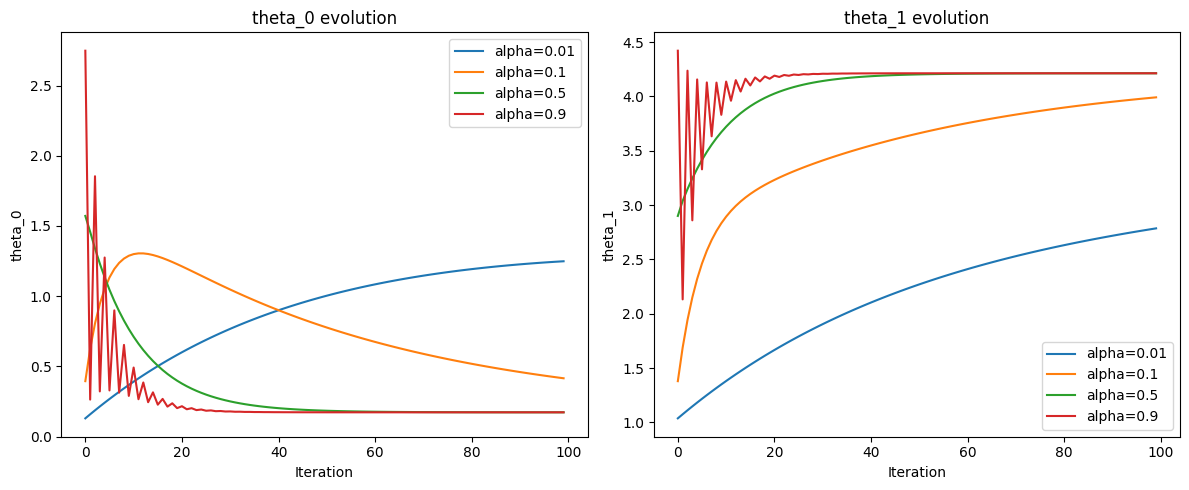

In [32]:
from re import sub
from os import error
import matplotlib.pyplot as plt

# Params
NMAX = 100
alphas = [0.01, 0.1, 0.5, 0.9] # CHANGE THIS

# YOUR CODE HERE
def step(theta_0, theta_1, xtrain, ytrain, alpha):
  ntrain = len(xtrain)
  ypred = theta_0 + theta_1*xtrain
  error = ypred - ytrain
  grad_0 = error.sum()/ntrain
  grad_1 = (error*xtrain).sum()/ntrain
  return theta_0 - alpha * grad_0, theta_1 - alpha * grad_1

plt.figure(figsize=(12,5))

for alpha in alphas:
  theta_0, theta_1 = 0.1, 1.0
  theta_0_history, theta_1_history = [],[]

  for i in range(NMAX):
    theta_0, theta_1 = step(theta_0, theta_1, X_train[:,0], y_train[:,0], alpha)
    theta_0_history.append(theta_0)
    theta_1_history.append(theta_1)

  plt.subplot(1,2,1)
  plt.plot(range(NMAX), theta_0_history, label=f"alpha={alpha}")
  plt.subplot(1,2,2)
  plt.plot(range(NMAX), theta_1_history, label=f'alpha={alpha}')

plt.subplot(1,2,1)
plt.xlabel("Iteration")
plt.ylabel("theta_0")
plt.title("theta_0 evolution")
plt.legend()

plt.subplot(1,2,2)
plt.xlabel("Iteration")
plt.ylabel("theta_1")
plt.title("theta_1 evolution")
plt.legend()
plt.tight_layout()
plt.show()

### Linear regression using `sklearn`

In [34]:
from numpy.random.mtrand import f
# Build and train the model using Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create a linear regression model object
# Check https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
model = LinearRegression()

# Train the model using our data
# The .fit() method is where the 'learning' (Gradient Descent) happens!
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R^2
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

#Show
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R^2: {train_r2:.4f}")
print(f"Testing R^2: {test_r2:.4f}")


Training MSE: 0.2099
Testing MSE: 0.0883
Training R^2: 0.9686
Testing R^2: 0.9810


In [15]:
# Analyze the results

# Get the learned parameters (theta_0 and theta_1)
# .intercept_ is an array, so we take the first element
theta_0 = model.intercept_[0]
# .coef_ is a 2D array, so we access it with [0][0]
theta_1 = model.coef_[0][0]
print(f"The model has learned the following equation:")
print(f"Force = {theta_0:.3f} + {theta_1:.3f} * Displacement\n")

print(f"The estimated spring constant (k) is: {theta_1:.3f} N/m")
print(f"The true spring constant was: {k_true} N/m")

y_test_sklearn = model.predict(X_test)

# Calculate the R-squared (R²) score.
# This metric measures how well the model's predictions approximate the real values.
# An R² of 1 indicates a perfect fit.
r2 = r2_score(y_test, y_test_sklearn)

# You can also calculate other metrics like Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_test_sklearn)

print(f"\n--- Model Evaluation ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")


The model has learned the following equation:
Force = 0.172 + 4.213 * Displacement

The estimated spring constant (k) is: 4.213 N/m
The true spring constant was: 4.5 N/m

--- Model Evaluation ---
R-squared (R²): 0.9810
Mean Squared Error (MSE): 0.0883


That's pretty close! Our model successfully estimated the spring constant from the noisy data. The small non-zero intercept `theta_0` is a result of the random noise we added; in a perfect world, it would be zero.

In [16]:
from bokeh.plotting import figure
from bokeh.io import output_notebook, show
import numpy as np
# --- Setup and Plotting ---
output_notebook()

# Create a figure with all properties set at once
p = figure(
    title="Hooke's Law with Model Fit",
    x_axis_label="Displacement (x) [m]",
    y_axis_label="Force (F) [N]",
    width=800, height=400
)

# Plot the original data
p.scatter(x_displacement[:, 0], y_force[:, 0], legend_label='Experimental Data', color='blue', line_color='black', size=10)

# Plot the regression line for our gradient descent
y_predicted_gd = new_theta_0 + new_theta_1*X_train
p.line(X_train[:, 0], y_predicted_gd[:, 0], legend_label='LinReg - GradientDescent', color='red', line_width=6)

y_predicted_sklearn = model.predict(X_train)
# Plot the regression line
p.line(X_train[:, 0], y_predicted_sklearn[:, 0], legend_label='LinReg - sklearn', color='green', line_width=3, alpha=0.7)

# Display the plot
show(p)

### Practice Exercises

Now it's your turn! Apply what you've learned to new scientific datasets.

````{exercise} Tensorflow/pytorch
:label: tensorflow
Implement the same example but using `tensorflow` and `pytorch`. Compare easy of use.
````


```{exercise} Biology - Brain vs. Body Weight

Allometry is the study of the relationship of body size to shape, anatomy, and physiology. It is a well-known fact that the brain weight of mammals generally increases with body weight. Let's model this relationship.

**Task:**
1.  Load the provided data for various mammal species.
2.  The relationship is often modeled on a log-log scale. First, amke a plot to justify that. Then, transform both `body_wt` and `brain_wt` by taking their natural logarithm (`np.log()`).
3.  Fit a linear regression model to the log-transformed data.
4.  Print the equation of your model.
5.  Plot the log-transformed data as a scatter plot and overlay your regression line.
```

In [38]:
from IPython.core import history
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data for Exercise 1
body_wt = np.array([3.385, 0.48, 1.35, 465.0, 36.33, 27.66, 1.04, 4.235, 10.55, 0.55, 1.0, 600.0, 3.5, 3.5, 6.8, 35.0, 3.92, 572.0, 180.0, 2.5, 1.92, 119.5, 85.0, 0.75, 14.83, 192.0])
brain_wt = np.array([44.5, 15.5, 8.1, 423.0, 119.5, 115.0, 5.5, 25.6, 73.5, 2.4, 6.6, 812.0, 10.8, 12.3, 37.0, 57.0, 17.5, 655.0, 157.0, 12.1, 11.4, 75.0, 62.0, 4.7, 48.0, 180.0])

# 1. (Data is already loaded)

# YOUR CODE HERE
print('Tensorflow')

tf_model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,))])
tf_model.compile(optimizer='sgd', loss='mse')
history_tf = tf_model.fit(body_wt, brain_wt, epochs=100, verbose=0, batch_size=10)
theta_1_tf = tf_model.layers[0].get_weights()[0][0][0]
theta_0_tf = tf_model.layers[0].get_weights()[1][0]
print(f'Results: theta_0 = {theta_0_tf:.4f}, theta_1 = {theta_1_tf:.4f}')
print(f'Loss: {history_tf.history['loss'][-1]:.6f}')

print('Pytorch')
body_wt_torch = torch.tensor(body_wt, dtype=torch.float32)


Tensorflow
Results: theta_0 = nan, theta_1 = nan
Loss: nan
Pytorch


In [39]:
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Datos del ejercicio anterior
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20]).reshape(-1, 1)

print("="*60)
print("COMPARACIÓN: TENSORFLOW vs PYTORCH")
print("="*60)

# ----- TENSORFLOW -----
print("\n🔵 TENSORFLOW Implementation:")
print("-"*40)

# Modelo TF
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

# Compilar
tf_model.compile(optimizer='sgd', loss='mse')

# Entrenar (solo 100 épocas para comparar)
history_tf = tf_model.fit(X, y, epochs=100, verbose=0, batch_size=10)

# Resultados TF
theta_1_tf = tf_model.layers[0].get_weights()[0][0][0]
theta_0_tf = tf_model.layers[0].get_weights()[1][0]
print(f"Resultados: theta_0 = {theta_0_tf:.4f}, theta_1 = {theta_1_tf:.4f}")
print(f"Loss final: {history_tf.history['loss'][-1]:.6f}")

# ----- PYTORCH -----
print("\n🟠 PYTORCH Implementation:")
print("-"*40)

# Convertir a tensores de torch
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

# Modelo PyTorch
class LinearRegressionTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

pt_model = LinearRegressionTorch()
criterion = nn.MSELoss()
optimizer = optim.SGD(pt_model.parameters(), lr=0.01)

# Entrenar
losses_pt = []
for epoch in range(100):
    optimizer.zero_grad()
    predictions = pt_model(X_torch)
    loss = criterion(predictions, y_torch)
    loss.backward()
    optimizer.step()
    losses_pt.append(loss.item())

# Resultados PyTorch
theta_1_pt = pt_model.linear.weight.item()
theta_0_pt = pt_model.linear.bias.item()
print(f"Resultados: theta_0 = {theta_0_pt:.4f}, theta_1 = {theta_1_pt:.4f}")
print(f"Loss final: {losses_pt[-1]:.6f}")

# ----- COMPARACIÓN -----
print("\n📊 COMPARACIÓN DE FACILIDAD DE USO:")
print("-"*40)
comparison = {
    "Aspecto": ["Instalación", "Curva de aprendizaje", "API", "Documentación", "Debugging", "Flexibilidad"],
    "TensorFlow": ["Moderada", "Media (Keras fácil)", "Keras simple, TF complejo", "Excelente", "Más difícil", "Alta"],
    "PyTorch": ["Fácil", "Más intuitiva", "Python puro", "Excelente", "Más fácil", "Muy alta"]
}

for i in range(len(comparison["Aspecto"])):
    print(f"{comparison['Aspecto'][i]:15} | TF: {comparison['TensorFlow'][i]:30} | PyTorch: {comparison['PyTorch'][i]}")

COMPARACIÓN: TENSORFLOW vs PYTORCH

🔵 TENSORFLOW Implementation:
----------------------------------------
Resultados: theta_0 = 0.2539, theta_1 = 1.9635
Loss final: 0.013931

🟠 PYTORCH Implementation:
----------------------------------------
Resultados: theta_0 = 0.0317, theta_1 = 1.9954
Loss final: 0.000217

📊 COMPARACIÓN DE FACILIDAD DE USO:
----------------------------------------
Instalación     | TF: Moderada                       | PyTorch: Fácil
Curva de aprendizaje | TF: Media (Keras fácil)            | PyTorch: Más intuitiva
API             | TF: Keras simple, TF complejo      | PyTorch: Python puro
Documentación   | TF: Excelente                      | PyTorch: Excelente
Debugging       | TF: Más difícil                    | PyTorch: Más fácil
Flexibilidad    | TF: Alta                           | PyTorch: Muy alta


:::{exercise} Using `SGDRegressor`
`sklearn` also offers the `SGDRegressor` to perform gradient descent. Use `SGDRegressor`, <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html>, and `partial_fit`, to get the loss function after each iteration. Finally, plot the loss function as a function of the iteration (for both training and testing). Do not forget to standardize the data. Gradient descent is sensible to that. BONUS if you use a `pipeline`, although there you need a trick for the `partial_fit`
:::

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline  # <--- New Import
from bokeh.plotting import figure
from bokeh.io import output_notebook, show

# --- Setup (Assuming X and y are defined) ---
output_notebook()

ALPHA = 0.01

# YOUR CODE HERE



In [41]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()

# ============================================
# 1. GENERAR DATOS DE EJEMPLO
# ============================================
np.random.seed(42)
n_samples = 200
X = np.random.randn(n_samples, 1) * 10
true_slope = 3.5
true_intercept = 2
y = true_intercept + true_slope * X.flatten() + np.random.randn(n_samples) * 5

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================================
# 2. CONFIGURACIÓN DEL SGDREGRESSOR
# ============================================
ALPHA = 0.01

sgd_regressor = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=ALPHA,
    max_iter=1,           # Una época por llamada
    shuffle=False,
    random_state=42,
    warm_start=True       # Mantener parámetros
)

# Crear pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', sgd_regressor)
])

# ============================================
# 3. ESCALAR LOS DATOS
# ============================================
# Escalar datos de entrenamiento y prueba
X_train_scaled = pipeline.named_steps['scaler'].fit_transform(X_train)
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)

# Obtener el regresor
regressor = pipeline.named_steps['sgd']

# ============================================
# 4. ENTRENAMIENTO ITERATIVO
# ============================================
train_losses = []
test_losses = []
epochs = []
N_EPOCHS = 50

for epoch in range(N_EPOCHS):
    # Una época de entrenamiento
    regressor.partial_fit(X_train_scaled, y_train)

    # Calcular pérdidas
    y_train_pred = regressor.predict(X_train_scaled)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_losses.append(train_mse)

    y_test_pred = regressor.predict(X_test_scaled)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_losses.append(test_mse)

    epochs.append(epoch + 1)

    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch+1:3d} - Train MSE: {train_mse:.4f} - Test MSE: {test_mse:.4f}")

# ============================================
# 5. RESULTADOS (CORREGIDO)
# ============================================
print("\n" + "="*50)
print("RESULTADOS FINALES")
print("="*50)

# Extraer coeficientes
coef_scaled = regressor.coef_[0]
intercept_scaled = regressor.intercept_

# Extraer media y desviación del scaler
mean = pipeline.named_steps['scaler'].mean_[0]
std = pipeline.named_steps['scaler'].scale_[0]

# Convertir a escala original (CORREGIDO)
coef_original = coef_scaled / std

# INTERCEPT_ORIGINAL puede ser array o float - lo normalizamos
if isinstance(intercept_scaled, np.ndarray):
    intercept_scaled_val = intercept_scaled[0]
else:
    intercept_scaled_val = intercept_scaled

intercept_original = intercept_scaled_val - coef_scaled * mean / std

print(f"Parámetros en escala ORIGINAL:")
print(f"  theta_1 (slope)     = {coef_original:.4f}  (True: {true_slope:.4f})")
print(f"  theta_0 (intercept) = {intercept_original:.4f}  (True: {true_intercept:.4f})")
print(f"\nPérdida final (MSE):")
print(f"  Train: {train_losses[-1]:.6f}")
print(f"  Test:  {test_losses[-1]:.6f}")

# ============================================
# 6. COMPARACIÓN CON LINEARREGRESSION
# ============================================
from sklearn.linear_model import LinearRegression

print("\n" + "="*50)
print("COMPARACIÓN CON SOLUCIÓN ANALÍTICA")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f"LinearRegression:")
print(f"  theta_1: {lr_model.coef_[0]:.4f}")
print(f"  theta_0: {lr_model.intercept_:.4f}")
print(f"\nSGDRegressor (después de {N_EPOCHS} épocas):")
print(f"  theta_1: {coef_original:.4f}")
print(f"  theta_0: {intercept_original:.4f}")

# Diferencia
diff_slope = abs(lr_model.coef_[0] - coef_original)
diff_intercept = abs(lr_model.intercept_ - intercept_original)
print(f"\nDiferencia entre modelos:")
print(f"  Slope:     {diff_slope:.6f}")
print(f"  Intercept: {diff_intercept:.6f}")

# ============================================
# 7. VISUALIZACIÓN CON BOKEH
# ============================================
p = figure(
    title="Evolución del MSE durante Gradient Descent",
    x_axis_label="Época",
    y_axis_label="MSE",
    width=800,
    height=500,
    tools="pan,box_zoom,reset,save"
)

p.line(epochs, train_losses, line_width=2, line_color="blue", legend_label="Train MSE")
p.line(epochs, test_losses, line_width=2, line_color="red", legend_label="Test MSE")

p.legend.location = "top_right"
p.legend.click_policy = "hide"
p.grid.grid_line_alpha = 0.3

show(p)

# ============================================
# 8. (OPCIONAL) VER EVOLUCIÓN DE PARÁMETROS
# ============================================
# Si quieres ver cómo evolucionan theta_0 y theta_1:
print("\n" + "="*50)
print("ANÁLISIS ADICIONAL")
print("="*50)

# Re-entrenar guardando parámetros
regressor2 = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=ALPHA,
    max_iter=1,
    warm_start=True,
    random_state=42
)

pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', regressor2)
])

X_train_scaled2 = pipeline2.named_steps['scaler'].fit_transform(X_train)
X_test_scaled2 = pipeline2.named_steps['scaler'].transform(X_test)
regressor2 = pipeline2.named_steps['sgd']

theta_0_history = []
theta_1_history = []

for epoch in range(N_EPOCHS):
    regressor2.partial_fit(X_train_scaled2, y_train)

    coef_s = regressor2.coef_[0]
    inter_s = regressor2.intercept_
    inter_s = inter_s[0] if isinstance(inter_s, np.ndarray) else inter_s

    # Convertir a escala original
    theta_1_orig = coef_s / std
    theta_0_orig = inter_s - coef_s * mean / std

    theta_0_history.append(theta_0_orig)
    theta_1_history.append(theta_1_orig)

# Graficar evolución de parámetros
from bokeh.layouts import gridplot

p1 = figure(title="Evolución de theta_0 (intercept)",
            x_axis_label="Época", y_axis_label="theta_0",
            width=400, height=400)
p1.line(epochs, theta_0_history, line_width=2, line_color="green")
p1.line(epochs, [true_intercept]*N_EPOCHS, line_width=2,
        line_color="gray", line_dash="dashed", legend_label="Valor real")

p2 = figure(title="Evolución de theta_1 (slope)",
            x_axis_label="Época", y_axis_label="theta_1",
            width=400, height=400)
p2.line(epochs, theta_1_history, line_width=2, line_color="orange")
p2.line(epochs, [true_slope]*N_EPOCHS, line_width=2,
        line_color="gray", line_dash="dashed", legend_label="Valor real")

grid = gridplot([[p1, p2]])
show(grid)

Época  10 - Train MSE: 23.3079 - Test MSE: 25.7202
Época  20 - Train MSE: 23.3079 - Test MSE: 25.7202
Época  30 - Train MSE: 23.3079 - Test MSE: 25.7202
Época  40 - Train MSE: 23.3079 - Test MSE: 25.7202
Época  50 - Train MSE: 23.3079 - Test MSE: 25.7202

RESULTADOS FINALES
Parámetros en escala ORIGINAL:
  theta_1 (slope)     = 3.5386  (True: 3.5000)
  theta_0 (intercept) = 2.5239  (True: 2.0000)

Pérdida final (MSE):
  Train: 23.307909
  Test:  25.720213

COMPARACIÓN CON SOLUCIÓN ANALÍTICA
LinearRegression:
  theta_1: 3.5700
  theta_0: 2.3563

SGDRegressor (después de 50 épocas):
  theta_1: 3.5386
  theta_0: 2.5239

Diferencia entre modelos:
  Slope:     0.031412
  Intercept: 0.167580



ANÁLISIS ADICIONAL


## Statistical tests for Linear Rregression

REF: <https://www.digitalocean.com/community/tutorials/multiple-linear-regression-python>

There are several assumptions when applying Linear Regression, the main one being the normality of residuals, but of course the linearity relationship, no-correlations among features and so on. The following table shows different test that can be applied to test how accurate those assumptions are.



### Assumptions of Multiple Linear Regression

| Assumption | Description | Test(s) to Check | Python Implementation (`pandas` + `seaborn`) |
| :--- | :--- | :--- | :--- |
| **1. Linearity** | The relationship between predictors (X) and the outcome (y) is linear. | **Scatter Plots** or **Fitted vs. Residuals Plot**. Look for a random scatter. Remember that you can tranform the data | `import seaborn as sns`<br>`# model is a fitted OLS model`<br>`residuals = model.resid`<br>`fitted = model.fittedvalues`<br>`sns.residplot(x=fitted, y=residuals, lowess=True)` |
| **2. Independence of Residuals** | The residuals (errors) are independent of each other (no autocorrelation). | **Durbin-Watson Test**. Look for a value around 2. | `from statsmodels.stats.stattools import durbin_watson`<br>`dw_stat = durbin_watson(model.resid)`<br>`print(f"Durbin-Watson: {dw_stat:.2f}")` |
| **3. Homoscedasticity** | Residuals have constant variance across all levels of X. | **Breusch-Pagan Test** or **White Test**. Look for a p-value > 0.05. Visual check with **Residuals vs. Fitted Plot**. | `import statsmodels.stats.api as sms`<br>`bp_test = sms.het_breuschpagan(model.resid, model.model.exog)`<br>`print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")` |
| **4. Normality of Residuals** | The residuals are approximately normally distributed. | **Jarque-Bera Test** or **Q-Q Plot**. Points on the Q-Q plot should follow the line. | `import statsmodels.api as sm`<br>`sm.qqplot(model.resid, line='s')`<br>`# Jarque-Bera result is in model.summary()` |
| **5. No Perfect Multicollinearity** | Independent variables are not highly correlated with each other. | **A) Correlation Matrix (Preliminary)**<br><br>**B) Variance Inflation Factor (VIF) (Definitive)** | `## A) Correlation Matrix`<br>`import seaborn as sns`<br>`import matplotlib.pyplot as plt`<br>`# df is your full DataFrame (X's and y)`<br>`corr_matrix = df.corr()`<br>`sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')`<br>`plt.show()`<br><br>`## B) VIF`<br>`from statsmodels.stats.outliers_influence import variance_inflation_factor`<br>`# X is a DataFrame of predictors only`<br>`vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]` |

It is also useful to check for the correlation between the dependent variable $Y$ and the independent variables $\vec X$. Large positive or negative correlations allow to select the most important variables for applying linear regression.

The following code shows an example of this:

---

### Full analysis workflow in Python

Here is a quick summary of how you would typically check these assumptions after fitting a model.



In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.api as sms

# 1. Prepare your data (assuming you have a pandas DataFrame `df`)
# Let's create some sample data for demonstration
np.random.seed(42)
X1 = np.random.rand(100) * 10
X2 = 0.5 * X1 + np.random.normal(0, 1, 100) # X2 is somewhat correlated with X1
X3 = np.random.rand(100) * 0.567
y = 2 + 3 * X1 + 5 * X2 + np.random.normal(0, 5, 100) + 0.01*X3
X = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3})
X = sm.add_constant(X) # Add a constant for the intercept

# 2. Fit the OLS model
model = sm.OLS(y, X).fit()
print(model.summary())
print("\n" + "="*80 + "\n")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     424.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.14e-55
Time:                        12:53:37   Log-Likelihood:                -289.78
No. Observations:                 100   AIC:                             587.6
Df Residuals:                      96   BIC:                             598.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4952      1.194      1.252      0.2

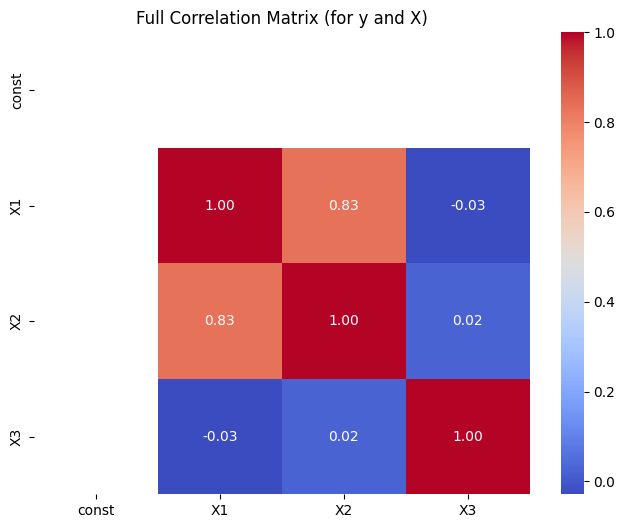

In [20]:
# --- Generate the Correlation Matrix ---
corr_matrix = X.corr()

# --- Visualize it with a Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Matrix (for y and X)')
plt.show()

In [21]:
# 2. Fit the OLS model
model = sm.OLS(y, X).fit()
print(model.summary())
print("\n" + "="*80 + "\n")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     424.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.14e-55
Time:                        12:53:37   Log-Likelihood:                -289.78
No. Observations:                 100   AIC:                             587.6
Df Residuals:                      96   BIC:                             598.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4952      1.194      1.252      0.2

In [22]:
print(model.pvalues)
significant_features = model.pvalues[model.pvalues < 0.05].index
print(significant_features)

const    2.134799e-01
X1       1.554354e-21
X2       8.749291e-13
X3       3.023342e-01
dtype: float64
Index(['X1', 'X2'], dtype='object')


Checking for Linearity and Homoscedasticity...


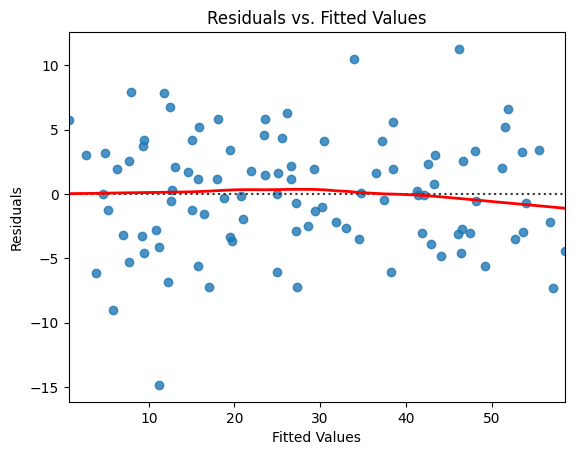

In [23]:
# 3. Check Assumptions

# --- Linearity & Homoscedasticity (Visual Check) ---
print("Checking for Linearity and Homoscedasticity...")
residuals = model.resid
fitted = model.fittedvalues
sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [24]:
# --- Homoscedasticity (Statistical Test) ---
print("Checking for Homoscedasticity (Breusch-Pagan Test)...")
bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.4f}")
if bp_test[1] > 0.05:
    print("Result: No evidence of heteroscedasticity (Good).")
else:
    print("Result: Evidence of heteroscedasticity found (Bad).")
print("\n" + "="*80 + "\n")

Checking for Homoscedasticity (Breusch-Pagan Test)...
Breusch-Pagan Test p-value: 0.2487
Result: No evidence of heteroscedasticity (Good).




In [25]:
# --- Independence of Residuals ---
print("Checking for Independence of Residuals (Durbin-Watson Test)...")
dw_stat = durbin_watson(model.resid)
print(f"Durbin-Watson statistic: {dw_stat:.2f}")
if 1.5 < dw_stat < 2.5:
    print("Result: No significant autocorrelation (Good).")
else:
    print("Result: Potential autocorrelation detected (Bad).")
print("\n" + "="*80 + "\n")

Checking for Independence of Residuals (Durbin-Watson Test)...
Durbin-Watson statistic: 2.32
Result: No significant autocorrelation (Good).




Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...


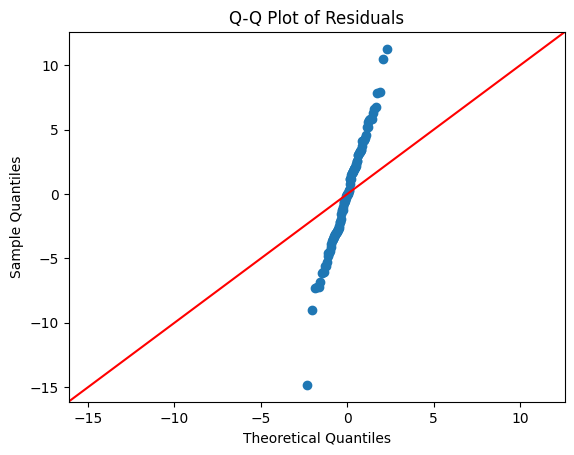

Jarque-Bera test probability: 2.324
Result: Residuals appear to be normally distributed (Good).




In [26]:
# --- Normality of Residuals ---
print("Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...")
sm.qqplot(model.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()
# The Jarque-Bera test result is in the model summary `Prob(JB)`
jb_prob = float(model.summary2().tables[2].iloc[0, 3])
print(f"Jarque-Bera test probability: {jb_prob}")
if jb_prob > 0.05:
     print("Result: Residuals appear to be normally distributed (Good).")
else:
     print("Result: Residuals may not be normally distributed (Bad).")
print("\n" + "="*80 + "\n")

In [27]:
# --- Multicollinearity ---
print("Checking for Multicollinearity (VIF)...")
# Note: We check VIF on the design matrix X without the constant
X_no_const = X.drop('const', axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X_no_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_no_const.values, i) for i in range(len(X_no_const.columns))]
print(vif_data)
if all(vif_data["VIF"] < 5):
    print("\nResult: No significant multicollinearity detected (Good).")
else:
    print("\nResult: Potential multicollinearity detected (Bad).")

Checking for Multicollinearity (VIF)...
  feature        VIF
0      X1  10.342441
1      X2  10.153508
2      X3   2.238342

Result: Potential multicollinearity detected (Bad).


## Regularization and MAP
The bias-variance trade-off shows that is important to not go to the extremes when fitting a model. For example, when the model performs well on the training data but does not work well on the test data, we might need to add a `regularization` so penalize the cost function to improve the trade-off and **avoid overfitting**. One example is the so-called ridge regularization, or $L_0$, where
\begin{equation}
\Delta(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat y(x_i) - y_i \right)^2 + \lambda \sum_{j=1}^{n} \theta_j^2,
\end{equation}
where $\lambda$ is the hyper-regularization parameter. This controls the magnitude of the coefficients preventing overfitting. When $\lambda$ is large, the parameters $\theta$ decrease, which shrinks the impact of variables no so correlated with the output. When $\lambda$ decreases, we basically converge to the usual linear regression.  

There are several other regularization techniques, such as lasso regression (L1),
\begin{equation}
\Delta(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x_i) - y_i \right)^2 + \lambda \sum_{j=1}^{n} |\theta_j|,
\end{equation}
Elastic Net regression, where both previous regressions are combines, and so on.

```python
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score

# Compare regularization methods
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} CV R²: {scores.mean():.3f} (±{scores.std()*2:.3f})")
```

### The bayesian approach
Actually, Adding a regularization term is analogous to assuming a prior distribution for the parameters, This is known as MAP: maximum a Posteriori, where a distribution on parameters is given and then maximum likelihood is used to estimate the best parameters.


In Bayesian inference, we find the weights $w$ by maximizing the **Posterior**:
$$p(w \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid w) \, p(w)}{p(\mathcal{D})}$$

To find the best weights, we maximize the **log-posterior**. Since the denominator $p(\mathcal{D})$ is a constant (it does not depend on $w$), we maximize the numerator:
$$\arg\max_{w} \left[ \ln p(\mathcal{D} \mid w) + \ln p(w) \right]$$

If we assume Gaussian noise for our likelihood (as derived in MSE), maximizing the log-likelihood is equivalent to minimizing the **Mean Squared Error (MSE)**. Therefore, the MAP objective becomes:
$$\arg\min_{w} \underbrace{\text{MSE}(w)}_{\text{Data Likelihood}} + \underbrace{\text{Loss}_{\text{prior}}(w)}_{\text{Negative Log-Prior}}$$

The "Regularization" we see in ML is simply the result of choosing different **prior distributions** for our weights.

---

### $L_2$ Regularization (Ridge): The Gaussian Prior
The simplest assumption is that weights are small and follow a **Gaussian (Normal) Distribution**. This assumes that large weights are extremely unlikely.

**The Prior:**
$$p(w_i) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{w_i^2}{2\sigma^2} \right)$$

**The Derivation:**
Taking the negative log-likelihood of this prior:
$$\text{Loss}_{\text{prior}}(w) = -\sum_{i=1}^{n} \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{w_i^2}{2\sigma^2}}\right)$$
$$\text{Loss}_{\text{prior}}(w) = \sum_{i=1}^{n} \left[ \ln(\sqrt{2\pi\sigma^2}) + \frac{w_i^2}{2\sigma^2} \right]$$

Dropping the constant term, we get the **Quadratic Penalty**:
$$\text{Loss}_{\text{prior}}(w) \propto \sum_{_i=1}^{n} w_i^2$$


Therefore,
$$\mathbf{w}^* = \arg\min_{\mathbf{w}}\ \sum_{i=1}^N (y_i - \mathbf{x}_i^\top \mathbf{w})^2 + \underbrace{\frac{\sigma^2}{\tau^2}}_{\lambda} \|\mathbf{w}\|_2^2$$

$$\boxed{\mathbf{w}^*_{\text{Ridge}} = \arg\min_{\mathbf{w}}\ \|\mathbf{y} - X\mathbf{w}\|_2^2 + \lambda\|\mathbf{w}\|_2^2}$$

A **narrow prior** (small $\tau^2$) $\Rightarrow$ large $\lambda$ $\Rightarrow$ strong shrinkage toward zero.

**Result:** $L_2$ regularization (Ridge) is the result of a Gaussian prior. It shrinks weights toward zero but rarely makes them exactly zero.

---

### $L_1$ Regularization (Lasso): The Laplace Prior
To achieve sparsity (true zero weights), we use a **Laplace Distribution**, which has a much sharper "peak" at zero than the Gaussian distribution.

**The Prior:**
$$p(w_i) = \frac{1}{2b} \exp\left( -\frac{|w_i|}{b} \right)$$

**The Derivation:**
Taking the negative log-likelihood of this prior:
$$\text{Loss}_{\text{prior}}(w) = -\sum_{i=1}^{n} \ln\left(\frac{1}{2b} e^{-\frac{|w_i|}{b}}\right)$$
$$\text{Loss}_{\text{prior}}(w) = \sum_{i=1}^{n} \left[ \ln(2b) + \frac{|w_i|}{b} \right]$$

Dropping the constant, we get the **Absolute Value Penalty**:
$$\text{SSim}_{\text{prior}}(w) \propto \sum_{i=1}^{n} |w_i|$$

Therefore,
$$\mathbf{w}^* = \arg\min_{\mathbf{w}}\ \sum_{i=1}^N (y_i - \mathbf{x}_i^\top \mathbf{w})^2 + \underbrace{\frac{\sigma^2}{b}}_{\lambda} \|\mathbf{w}\|_1$$

$$\boxed{\mathbf{w}^*_{\text{Lasso}} = \arg\min_{\mathbf{w}}\ \|\mathbf{y} - X\mathbf{w}\|_2^2 + \lambda\|\mathbf{w}\|_1}$$

**Result:** $L_1$ regularization (Lasso) is the result of a Laplace prior. The "sharpness" of the peak at zero forces many weights to become exactly zero.

---

### Summary Table

| Regularization | Prior Distribution | Penalty Function | Mathematical Property |
| :--- | :--- | :--- | :--- |
| **None (MLE)** | Uniform / Flat | $0$ | Unbiased, High Variance |
| **$L_2$ (Ridge)** | **Gaussian** | $\sum w_i^2$ | Smooth shrinkage |
| **$L_1$ (Lasso)** | **Laplace** | $\sum \|w_i\|$ | Sparse / Feature selection |


### Regularization Exercises
:::{exercise} Ridge, lasso and elastic net
Implement ridge regularization into our step by step approach. Check the role of several values. Now do the same for lasso, and then for Elastic Net.
:::

:::{exercise} Ransac regression with outliers
Look for ransac regression in sklearn and implement an example showing how ransac can ignore outliers in data.
:::

## Exercises

For the following exercises, perform a full analysis with explicit statistical tests computation and interpretation. Explain why you use some of the features, or why you need to use all of them. Plot correlation matrices and so on. Also perform a previous pre-processing stage.   

:::{exercise} A large number of features model
Use [sklearn.datasets.make_regression](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html#sklearn.datasets.make_regression) to generate a 100 features model but 10 relevant features. Use feture selection to select less features

```python
from sklearn.feature_selection import RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_scaled, y)
print("Selected Features:", rfe.support_)

# Bar Plot of Feature Rankings
feature_ranking = pd.DataFrame({
   'Feature': selected_features,
   'Ranking': rfe.ranking_
})
feature_ranking.sort_values(by='Ranking').plot(kind='bar', x='Feature', y='Ranking', legend=False)
plt.title('Feature Ranking (Lower is Better)')
plt.ylabel('Ranking')
plt.show()
```
:::

:::{exercise} Star dataset
Use the star dataset to try to predict luminosity: <https://www.kaggle.com/datasets/waqi786/stars-dataset>.
:::

:::{exercise} Polynomial regression
Generate a random set following the model
\begin{equation}
y = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \epsilon
\end{equation}
and apply (polynomial) linear regression to get the coefficients.  Check <https://www.geeksforgeeks.org/machine-learning/python-implementation-of-polynomial-regression/>
:::